In [1]:
# Configuration
import os
import sys

os.environ["KERAS_BACKEND"] = "jax"
sys.path.append("..")

In [2]:
# Setup
from importlib import import_module

import numpy as np
from keras import ops
from rich.console import Console
from rich.table import Table

from src.models import (
    GradientBoostedDecisionTree,
    LearnableCutFlowParallel,
    LearnableCutFlowSequential,
    MultiLayerPerceptron,
)
from src.utils import load_model, show_record_dataset, show_record_dataset_correlation

In [3]:
# Parameters
experiment_id = "4.6"

# Dataset
dataset_name = "mock6"
n_samples = 200000
seed = 42

# Model
centers = [-2, 2, 0, 0, -1, -5, -1.8]
n_epochs = 200
batch_size = 512

# Figure
bins = np.linspace(-10, 10, 101)
feature_names = ["x1", "x2", "x3", "x4", "x5", "x7", "x9"]
feature_names_latex = ["$x_1$", "$x_2$", "$x_3$", "$x_4$", "$x_5$", "$x_7$", "$x_9$"]

x_train.shape=(100000, 7)
y_train.shape=(100000, 1)
x_test.shape=(100000, 7)
y_test.shape=(100000, 1)


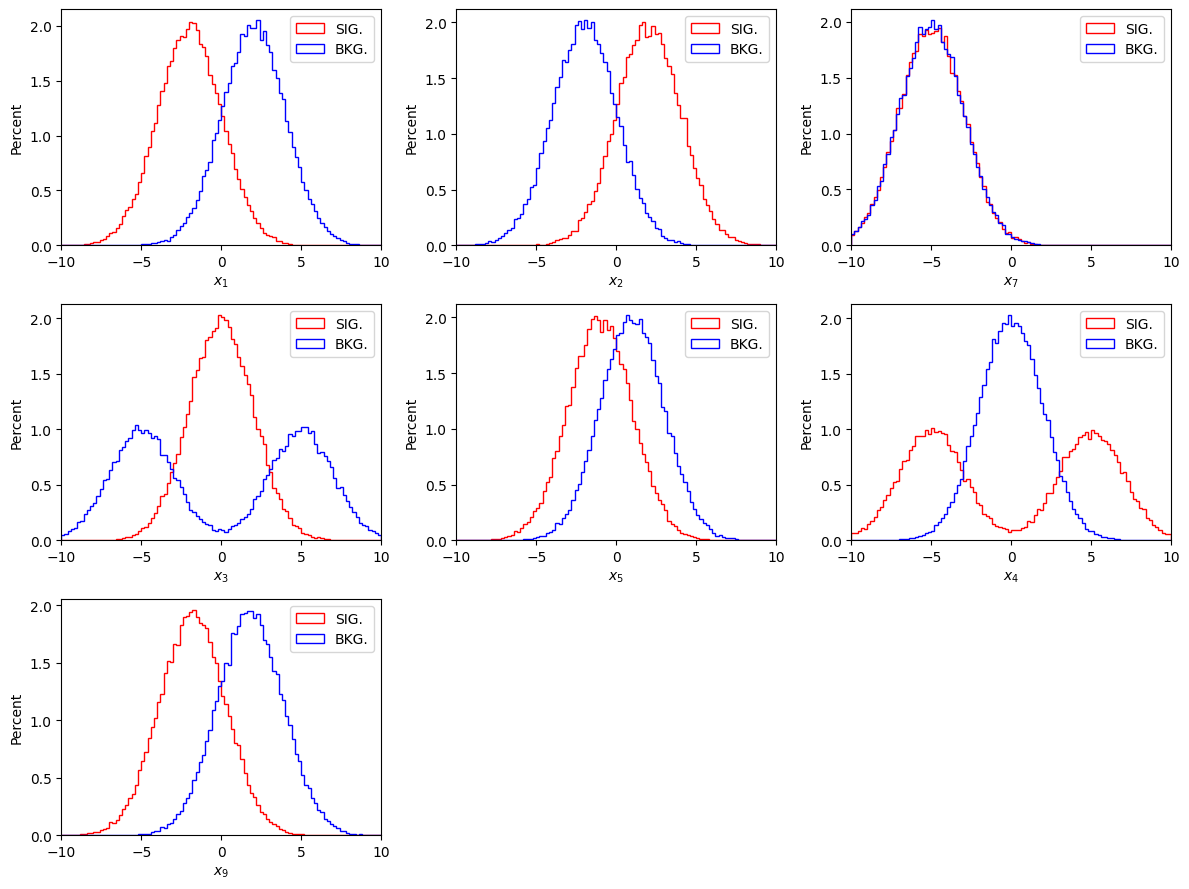

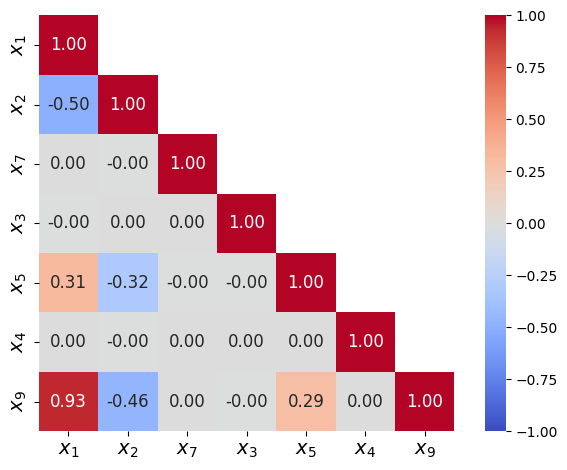

In [4]:
# Dataset
load_data = import_module(f"src.datasets.{dataset_name}").load_data
(x_train, y_train), (x_test, y_test), order = load_data(n_samples, seed)

centers = [centers[i] for i in order]
feature_names = [feature_names[i] for i in order]
feature_names_latex = [feature_names_latex[i] for i in order]

print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

# Figure: feature distribution
show_record_dataset(x_train, y_train, bins, feature_names_latex)

# Figure: feature correlation
show_record_dataset_correlation(x_train, feature_names_latex)

In [5]:
# Model: gradient boosted decision tree
bdt = GradientBoostedDecisionTree(input_shape=x_train.shape, name="bdt")

bdt.compile(optimizer="adam", loss="crossentropy")
bdt.fit(x_train, y_train.squeeze(), epochs=n_epochs, batch_size=batch_size)

bdt.save(f"checkpoints/{experiment_id}-{bdt.name}.pkl")
ckpt_bdt = load_model(f"checkpoints/{experiment_id}-{bdt.name}.pkl")

In [6]:
# Model: multi-layer perceptron
mlp = MultiLayerPerceptron(input_shape=x_train.shape, name="mlp")

mlp.layers[1].adapt(x_train)
mlp.compile(optimizer="adam", loss="crossentropy")
mlp.fit(x_train, y_train, epochs=n_epochs, batch_size=batch_size)

mlp.save(f"checkpoints/{experiment_id}-{mlp.name}.keras")
ckpt_mlp = load_model(f"checkpoints/{experiment_id}-{mlp.name}.keras")

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.3488
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0612
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0543
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0515
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0512
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0503
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0506
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0503
Epoch 9/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0509
Epoch 10/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0491 
Epoch 11/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0492
Epoch 12/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0488
Epoch 13/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0484
Epoch 14/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0500
Epoch 15/200
196/196 ━━━━━━━━━━━━━━━━━━━━

In [7]:
# Model: learnable cut flow parallel
lcf_par = LearnableCutFlowParallel(
    x_train.shape,
    centers,
    feature_names=feature_names,
    name="lcf_par",
)

lcf_par.normalization.adapt(x_train)
lcf_par.compile(optimizer="adam", loss="crossentropy")
lcf_par.fit(x_train, y_train, epochs=n_epochs, batch_size=batch_size)

lcf_par.save(f"checkpoints/{experiment_id}-{lcf_par.name}.keras")
ckpt_lcf_par = load_model(f"checkpoints/{experiment_id}-{lcf_par.name}.keras")

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.3611
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3419
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3284
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3187
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3110
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3051
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3004
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2960
Epoch 9/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2928
Epoch 10/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2898
Epoch 11/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2873
Epoch 12/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2846
Epoch 13/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2827
Epoch 14/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2808
Epoch 15/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 

In [8]:
# Model: learnable cut flow sequential
lcf_seq = LearnableCutFlowSequential(
    x_train.shape,
    centers,
    feature_names=feature_names,
    name="lcf_seq",
)

lcf_seq.normalization.adapt(x_train)
lcf_seq.compile(optimizer="adam", loss="crossentropy")
lcf_seq.fit(x_train, y_train, epochs=n_epochs, batch_size=batch_size)

lcf_seq.save(f"checkpoints/{experiment_id}-{lcf_seq.name}.keras")
ckpt_lcf_seq = load_model(f"checkpoints/{experiment_id}-{lcf_seq.name}.keras")

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0564
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0513
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0459
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0513
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0833
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0905
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0919
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1105
Epoch 9/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1162
Epoch 10/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1138
Epoch 11/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1136
Epoch 12/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1118
Epoch 13/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1116
Epoch 14/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1091
Epoch 15/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 

In [9]:
# Analysis: metrics
results = []
y_true = y_test

console = Console(force_jupyter=False)
table = Table(title="Model Performance Comparison")
table.add_column("#", justify="center", style="cyan", no_wrap=True)
table.add_column("Model", style="magenta")
table.add_column("TP", justify="right", style="green")
table.add_column("FP", justify="right", style="red")
table.add_column("Accuracy", justify="right", style="blue")
table.add_column("Precision", justify="right", style="blue")
table.add_column("Significance", justify="right", style="yellow")

for i, model in enumerate([bdt, mlp, lcf_par, lcf_seq]):
    y_pred = model.predict(x_test, batch_size=batch_size, verbose=0)
    y_pred = ops.all(y_pred > 0.5, axis=1, keepdims=True)

    tp = ops.sum((y_true == 1) & (y_pred == 1))
    fp = ops.sum((y_true == 0) & (y_pred == 1))
    tn = ops.sum((y_true == 0) & (y_pred == 0))
    fn = ops.sum((y_true == 1) & (y_pred == 0))

    n_preds_true = ops.add(tp, tn)
    n_preds_false = ops.add(fp, fn)
    n_positives = ops.add(tp, fp)
    n_samples = ops.add(n_preds_true, n_preds_false)

    accuracy = ops.divide(n_preds_true, n_samples)
    precision = ops.divide(tp, n_positives)
    significance = ops.divide(tp, ops.sqrt(fp))

    table.add_row(
        str(i + 1),
        model.name,
        f"{tp:.0f}",
        f"{fp:.0f}",
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{significance:.4f}",
    )

console.print(table)

                    Model Performance Comparison                    
┏━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ # ┃ Model   ┃    TP ┃   FP ┃ Accuracy ┃ Precision ┃ Significance ┃
┡━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ 1 │ bdt     │ 49111 │  979 │   0.9800 │    0.9805 │    1569.5945 │
│ 2 │ mlp     │ 49068 │ 1126 │   0.9781 │    0.9776 │    1462.2754 │
│ 3 │ lcf_par │ 16335 │    6 │   0.6620 │    0.9996 │    6668.7358 │
│ 4 │ lcf_seq │ 40180 │ 1585 │   0.8846 │    0.9620 │    1009.2420 │
└───┴─────────┴───────┴──────┴──────────┴───────────┴──────────────┘
